# Работа 6. Бинарная классификация: предсказание выживания на «Титанике»

Задача — по данным о пассажире предсказать значение признака `Survived` (0 или 1).

Воспроизводимость: единственный источник случайности в ноутбуке — константа
`RANDOM_STATE`, она передаётся в разбиение выборки, в кросс-валидацию и во все модели.

## 1. Чтение датасета

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd

RANDOM_STATE = 42          # фиксируем случайность один раз на весь ноутбук


def find_dataset(filename: str = "train.csv") -> Path:
    """Ищет DataSet/<filename>, поднимаясь от текущей папки вверх по дереву."""
    start = Path.cwd()
    for folder in [start, *start.parents]:
        candidate = folder / "DataSet" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Не найдена папка DataSet с файлом {filename}")


df = pd.read_csv(find_dataset(), index_col="PassengerId")
print(f"строк: {df.shape[0]}, столбцов: {df.shape[1]}")
df.head()

строк: 891, столбцов: 11


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Выбор метрики

In [4]:
balance = df["Survived"].value_counts().sort_index()
print("Баланс классов:")
for value, count in balance.items():
    label = "погиб" if value == 0 else "выжил"
    print(f"  {value} ({label}): {count:>3} чел.  {count / len(df) * 100:5.1f}%")

print(f"\nДоля большинства (константное предсказание «все погибли»): "
      f"{balance.max() / len(df):.4f}")
print(f"Пропуски в признаках:\n{df.isna().sum()[lambda s: s > 0].to_string()}")

Баланс классов:
  0 (погиб): 549 чел.   61.6%
  1 (выжил): 342 чел.   38.4%

Доля большинства (константное предсказание «все погибли»): 0.6162
Пропуски в признаках:
Age         177
Cabin       687
Embarked      2


### Обоснование выбора метрики

Классы несбалансированы умеренно (62% / 38%), поэтому **accuracy как единственная
метрика непригодна**: модель, всегда отвечающая «погиб», получит 0.62 и создаст
видимость работы, не найдя ни одного выжившего. Цена ошибок здесь симметрична —
задача учебная, и пропустить выжившего так же плохо, как ошибочно объявить
выжившим погибшего, — поэтому за основную метрику берём **F1-score по классу
«выжил»**: он одновременно штрафует и за пропуски, и за ложные срабатывания.

Дополнительно смотрим на **ROC-AUC**: он не зависит от выбранного порога и
показывает качество ранжирования, то есть насколько уверенно модель отделяет
классы в принципе. `precision`, `recall` и `accuracy` выводим справочно — они
объясняют, из чего сложился F1, но решение по ним не принимаем.

## 3. Разбиение на тренировочную и тестовую выборки

In [5]:
from sklearn.model_selection import train_test_split

TARGET = "Survived"
# Name, Ticket и Cabin в исходном виде не используем: первые два почти уникальны
# для каждого пассажира, а Cabin пуст у 77% строк. Факт наличия каюты сохраним
# отдельным признаком ниже.
FEATURES = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "Cabin"]

X = df[FEATURES].copy()
y = df[TARGET]

# stratify=y сохраняет пропорцию выживших в обеих выборках: без него на тесте
# из 179 человек баланс классов может заметно сдвинуться и метрика поплывёт
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"тренировочная выборка: {X_train.shape[0]} строк")
print(f"тестовая выборка:      {X_test.shape[0]} строк")
print(f"доля выживших в train: {y_train.mean():.4f}")
print(f"доля выживших в test:  {y_test.mean():.4f}")

тренировочная выборка: 712 строк
тестовая выборка:      179 строк
доля выживших в train: 0.3834
доля выживших в test:  0.3855


## 4. Предобработка данных

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler


def add_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Два производных признака вместо сырых столбцов.

    FamilySize — сколько всего родственников на борту вместе с самим пассажиром:
    SibSp и Parch по отдельности плохо описывают ситуацию, а одиночки и большие
    семьи выживали по-разному.

    HasCabin — известен ли номер каюты. Сам номер использовать нельзя (пропущен
    у 77% строк), но сам факт записи каюты косвенно говорит о классе билета.
    """
    frame = frame.copy()
    frame["FamilySize"] = frame["SibSp"] + frame["Parch"] + 1
    frame["HasCabin"] = frame["Cabin"].notna().astype(int)
    return frame.drop(columns=["Cabin"])


def derived_names(transformer, input_features) -> np.ndarray:
    """Имена столбцов после add_features: Cabin уходит, два признака добавляются.

    sklearn требует объявить состав столбцов на выходе заранее — иначе
    ColumnTransformer не сможет сослаться на них по имени.
    """
    kept = [name for name in input_features if name != "Cabin"]
    return np.array([*kept, "FamilySize", "HasCabin"])


NUMERIC = ["Age", "Fare", "SibSp", "Parch", "FamilySize"]
CATEGORICAL = ["Pclass", "Sex", "Embarked", "HasCabin"]

# Числовые: медиана вместо пропусков (у Age их 20%, среднее чувствительно
# к пожилым выбросам), затем стандартизация — логистической регрессии она нужна,
# иначе Fare со шкалой до 512 подавит остальные признаки
numeric_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

# Категориальные: самое частое значение вместо пропусков (в Embarked их два),
# затем one-hot. handle_unknown="ignore" страхует от категории, не встретившейся
# в обучении; drop="if_binary" убирает избыточный второй столбец у Sex и HasCabin
categorical_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore", drop="if_binary",
                             sparse_output=False)),
])

preprocessor = Pipeline([
    ("derive", FunctionTransformer(add_features, feature_names_out=derived_names)),
    ("columns", ColumnTransformer([
        ("num", numeric_pipeline, NUMERIC),
        ("cat", categorical_pipeline, CATEGORICAL),
    ])),
])

# Проверяем, что предобработка отрабатывает и что получается на выходе
sample = preprocessor.fit_transform(X_train)
print(f"после предобработки: {sample.shape[0]} строк, {sample.shape[1]} признаков")
print("признаки:", list(preprocessor.named_steps["columns"].get_feature_names_out()))

после предобработки: 712 строк, 13 признаков
признаки: ['num__Age', 'num__Fare', 'num__SibSp', 'num__Parch', 'num__FamilySize', 'cat__Pclass_1', 'cat__Pclass_2', 'cat__Pclass_3', 'cat__Sex_male', 'cat__Embarked_C', 'cat__Embarked_Q', 'cat__Embarked_S', 'cat__HasCabin_1']


## 5. Бейзлайн: константные и случайные предсказания

In [7]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score)


def evaluate(name: str, model, X_eval, y_eval) -> dict:
    """Считает все метрики одним вызовом. ROC-AUC берётся по вероятностям."""
    predictions = model.predict(X_eval)
    probabilities = model.predict_proba(X_eval)[:, 1]
    return {
        "модель": name,
        "f1": round(f1_score(y_eval, predictions), 4),
        "roc_auc": round(roc_auc_score(y_eval, probabilities), 4),
        "precision": round(precision_score(y_eval, predictions, zero_division=0), 4),
        "recall": round(recall_score(y_eval, predictions), 4),
        "accuracy": round(accuracy_score(y_eval, predictions), 4),
    }


baselines = {
    "бейзлайн: самый частый класс": DummyClassifier(strategy="most_frequent"),
    "бейзлайн: случайно по частотам": DummyClassifier(strategy="stratified",
                                                      random_state=RANDOM_STATE),
}

results = []
for name, model in baselines.items():
    model.fit(X_train, y_train)
    results.append(evaluate(name, model, X_test, y_test))

pd.DataFrame(results).set_index("модель")

,f1,roc_auc,precision,recall,accuracy
модель,,,,,
бейзлайн: самый частый класс,0.0000,0.5000,0.0000,0.0000,0.6145
бейзлайн: случайно по частотам,0.3485,0.4848,0.3651,0.3333,0.5196


Константный бейзлайн набирает accuracy 0.62, но F1 у него равен нулю: он не
находит ни одного выжившего. Это ровно та ловушка, из-за которой accuracy была
отвергнута как основная метрика. ROC-AUC = 0.5 у обоих бейзлайнов означает
отсутствие способности ранжировать — то есть предсказания не лучше подбрасывания
монеты.

## 6. ML-модели

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

models = {
    "логистическая регрессия": LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE
    ),
    "случайный лес": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

# Кросс-валидация на тренировочной выборке: тестовую не трогаем до самого конца,
# иначе оценка перестанет быть честной
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
pipelines = {}
for name, estimator in models.items():
    pipeline = Pipeline([("prep", preprocessor), ("model", estimator)])
    pipelines[name] = pipeline
    scores = cross_validate(pipeline, X_train, y_train, cv=cv,
                            scoring=["f1", "roc_auc"])
    cv_rows.append({
        "модель": name,
        "f1 (среднее)": round(scores["test_f1"].mean(), 4),
        "f1 (разброс)": round(scores["test_f1"].std(), 4),
        "roc_auc (среднее)": round(scores["test_roc_auc"].mean(), 4),
        "roc_auc (разброс)": round(scores["test_roc_auc"].std(), 4),
    })

print("Кросс-валидация на тренировочной выборке (5 фолдов):")
pd.DataFrame(cv_rows).set_index("модель")

Кросс-валидация на тренировочной выборке (5 фолдов):


,f1 (среднее),f1 (разброс),roc_auc (среднее),roc_auc (разброс)
модель,,,,
логистическая регрессия,0.7368,0.0242,0.8596,0.0217
случайный лес,0.7585,0.0316,0.8802,0.0115


## 7. Оценка на отложенной выборке

In [9]:
for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)                 # обучаем на train целиком
    results.append(evaluate(name, pipeline, X_test, y_test))

comparison = pd.DataFrame(results).set_index("модель")
comparison

,f1,roc_auc,precision,recall,accuracy
модель,,,,,
бейзлайн: самый частый класс,0.0000,0.5000,0.0000,0.0000,0.6145
бейзлайн: случайно по частотам,0.3485,0.4848,0.3651,0.3333,0.5196
логистическая регрессия,0.7287,0.8379,0.7833,0.6812,0.8045
случайный лес,0.6977,0.8408,0.7500,0.6522,0.7821


In [10]:
best_name = comparison["f1"].idxmax()
best_f1 = comparison.loc[best_name, "f1"]
baseline_f1 = comparison.loc["бейзлайн: самый частый класс", "f1"]
baseline_accuracy = comparison.loc["бейзлайн: самый частый класс", "accuracy"]

print(f"Лучшая модель по F1: {best_name}")
print(f"  F1:       {best_f1:.4f}  (бейзлайн: {baseline_f1:.4f})")
print(f"  ROC-AUC:  {comparison.loc[best_name, 'roc_auc']:.4f}  (бейзлайн: 0.5000)")
print(f"  accuracy: {comparison.loc[best_name, 'accuracy']:.4f}  "
      f"(бейзлайн: {baseline_accuracy:.4f})")

Лучшая модель по F1: логистическая регрессия
  F1:       0.7287  (бейзлайн: 0.0000)
  ROC-AUC:  0.8379  (бейзлайн: 0.5000)
  accuracy: 0.8045  (бейзлайн: 0.6145)


## 8. Матрица ошибок и ROC-кривые

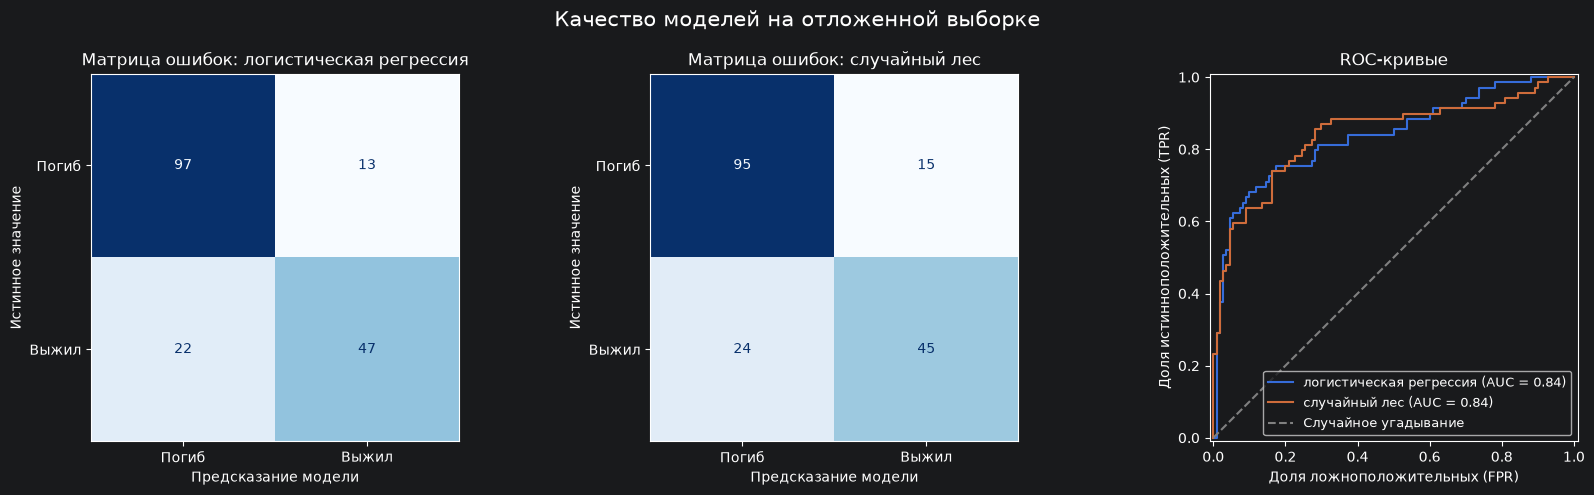

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Качество моделей на отложенной выборке", fontsize=15)

for ax, (name, pipeline) in zip(axes[:2], pipelines.items()):
    ConfusionMatrixDisplay.from_estimator(
        pipeline, X_test, y_test, ax=ax, cmap="Blues", colorbar=False,
        display_labels=["Погиб", "Выжил"],
    )
    ax.set_title(f"Матрица ошибок: {name}")
    ax.set_xlabel("Предсказание модели")
    ax.set_ylabel("Истинное значение")

ax = axes[2]
for name, pipeline in pipelines.items():
    RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Случайное угадывание")
ax.set_title("ROC-кривые")
ax.set_xlabel("Доля ложноположительных (FPR)")
ax.set_ylabel("Доля истинноположительных (TPR)")
ax.legend(loc="lower right", fontsize=9)

fig.tight_layout()
plt.show()

## 9. Выводы

In [12]:
summary = comparison.copy()
summary["прирост F1 к бейзлайну"] = (summary["f1"] - baseline_f1).round(4)
summary

,f1,roc_auc,precision,recall,accuracy,прирост F1 к бейзлайну
модель,,,,,,
бейзлайн: самый частый класс,0.0000,0.5000,0.0000,0.0000,0.6145,0.0000
бейзлайн: случайно по частотам,0.3485,0.4848,0.3651,0.3333,0.5196,0.3485
логистическая регрессия,0.7287,0.8379,0.7833,0.6812,0.8045,0.7287
случайный лес,0.6977,0.8408,0.7500,0.6522,0.7821,0.6977


### Что показали результаты

**Обе модели уверенно бьют бейзлайн.** Константное предсказание «все погибли» даёт
accuracy 0.6145 при F1 = 0: оно не находит ни одного выжившего и как классификатор
бесполезно. Логистическая регрессия даёт F1 = 0.7287 и ROC-AUC = 0.8379 — то есть
модель действительно извлекла закономерность, а не подстроилась под баланс классов.

**Расхождение между кросс-валидацией и тестом.** На кросс-валидации лучше выглядел
случайный лес (F1 = 0.7585 против 0.7368), но на отложенной выборке победила
логистическая регрессия (0.7287 против 0.6977). Разница в 0.03 сопоставима с
разбросом между фолдами (±0.03), а тестовая выборка мала — 179 человек, где каждый
объект стоит около 0.6% метрики. Считать одну модель уверенно лучше другой
оснований нет; при равном качестве разумно выбрать более простую и
интерпретируемую логистическую регрессию.

**Где модель ошибается.** При precision 0.78 и recall 0.68 модель пропускает
примерно треть выживших: она осторожна и склонна относить пассажира к погибшим.
Если бы задача требовала находить всех выживших любой ценой, стоило бы понизить
порог классификации и смотреть на recall или F-beta с β > 1 — но для симметричной
постановки текущий баланс адекватен.

**Воспроизводимость.** Все источники случайности зафиксированы одной константой
`RANDOM_STATE = 42`: разбиение выборки, перемешивание фолдов, случайный бейзлайн
и обе модели. Ноутбук выполняется от начала до конца без ошибок.